# Training mô hình ResNet50 cho FER2013 (ảnh HR 224×224, Kaggle)

Ngoài các kỹ thuật tiền xử lí và tăng cường dữ liệu ở mức ảnh đầu vào, chúng tôi còn sử dụng nhiều kỹ thuật ở **mức mô hình và quy trình huấn luyện** để giảm overfitting và cải thiện khả năng tổng quát hoá:
#### 1. Transfer learning với ResNet50 pretrained trên ImageNet  

- Sử dụng backbone **ResNet50** đã được huấn luyện sẵn trên ImageNet.  
- Ở giai đoạn đầu, **đóng băng toàn bộ** các lớp của ResNet50 và chỉ huấn luyện phần head phía trên.  
- Lợi ích:
  - Tận dụng các đặc trưng thị giác chung đã học từ ImageNet.
  - Giảm số lượng tham số cần cập nhật, hạn chế overfitting khi dữ liệu bài toán không quá lớn.

---

#### 2. Huấn luyện hai giai đoạn (2-stage training)  

1. **Stage 1 – Freeze backbone**  
   - ResNet50 giữ nguyên trọng số (không train).  
   - Chỉ huấn luyện khối phân loại: `GlobalAveragePooling2D → Dropout → Dense(softmax)`.  
   - Learning rate tương đối lớn hơn để head học nhanh bộ phân loại cơ bản trên không gian đặc trưng cố định.

2. **Stage 2 – Fine-tune một phần ResNet**  
   - Chỉ **mở một số lớp sâu ở cuối** ResNet50 (các layer gần output).  
   - Fine-tune với **learning rate rất nhỏ** để tinh chỉnh nhẹ đặc trưng mức cao cho bài toán cảm xúc.

Cách train hai bước giúp cải thiện độ chính xác mà vẫn hạn chế overfitting, vì backbone không bị “phá” quá nhiều.

---

#### 3. Regularization ở mức mô hình: Dropout + L2  

- Sau lớp GlobalAveragePooling2D, chèn **Dropout** (khoảng 0.35–0.40) để ngẫu nhiên tắt một phần neuron trong quá trình học.  
  → Mô hình buộc phải dựa trên **tập hợp nhiều đặc trưng khác nhau**, thay vì phụ thuộc vào vài chiều đặc trưng cụ thể.  
- Lớp Dense cuối cùng dùng **L2 kernel regularization** với hệ số nhỏ `λ ≈ 1e-4`.  
  → Phạt các trọng số có giá trị quá lớn, hạn chế hiện tượng “học thuộc lòng” dữ liệu train.

---

#### 4. Label smoothing trong hàm loss  

- Hàm mất mát sử dụng **Categorical Cross-Entropy** kết hợp **label smoothing nhẹ** ở giai đoạn fine-tune.  
- Thay vì one-hot tuyệt đối, một phần nhỏ xác suất được phân bổ sang các lớp còn lại.  
- Tác dụng:
  - Mô hình **bớt quá tự tin** vào một lớp duy nhất.
  - Giảm nhạy cảm với nhiễu trong nhãn và giúp quá trình huấn luyện ổn định, ít overfitting hơn.

---

#### 5. Class weight cho bài toán mất cân bằng lớp  

- Phân bố cảm xúc trong FER2013 không đồng đều, một số lớp (như *disgust*) có rất ít mẫu.  
- Đồ án tính **class_weight** dựa trên tần suất xuất hiện của từng lớp, sau đó:
  - Chuẩn hoá để trung bình ≈ 1.0.  
  - **Cắt ngưỡng trên** (ví dụ `max_weight = 3.0`) để tránh trọng số quá cực đoan.  
- Khi huấn luyện, các lớp hiếm được gán trọng số cao hơn trong hàm loss → mô hình không bỏ qua các lớp này, cải thiện accuracy tổng thể trên validation.

---

#### 6. Các callback điều khiển quá trình học  

- **ModelCheckpoint**  
  - Lưu lại mô hình có **`val_accuracy` tốt nhất** ở mỗi giai đoạn.  
  - Đảm bảo mô hình dùng để đánh giá thực nghiệm luôn là phiên bản tốt nhất trên tập validation.

- **ReduceLROnPlateau**  
  - Theo dõi `val_loss`, nếu loss không cải thiện sau một số epoch sẽ **tự động giảm learning rate** (thường nhân với một hệ số < 1).  
  - Cho phép mô hình “học tinh” hơn ở những giai đoạn cuối, hạn chế dao động và overfitting.

- **EarlyStopping**  
  - Dừng huấn luyện nếu `val_accuracy` không được cải thiện trong một số epoch liên tiếp.  
  - Tự động **khôi phục trọng số tại epoch tốt nhất**.  
  - Giúp tránh train quá lâu, giảm thời gian huấn luyện và giảm nguy cơ mô hình bắt đầu overfit.


### 1. Khởi tạo môi trường và kiểm tra dataset trên Kaggle


In [1]:
# 1) Liệt kê tất cả folder/dataset hiện có trong môi trường Kaggle
#    (dùng để kiểm tra tên folder sau khi Add Dataset/Add Data)
!ls /kaggle/input

# 2) Khai báo đường dẫn dataset FER2013 đã tiền xử lý (HR 224x224)
#    DATA_DIR trỏ tới thư mục gốc chứa 3 folder con: train, val, test
DATA_DIR = "/kaggle/input/fer2013-tien-xu-li/FER2013_tien_xu_li"
print("DATA_DIR =", DATA_DIR)

# 3) Xem nhanh cấu trúc thư mục bên trong DATA_DIR
#    Mục đích: xác nhận có đủ train / val / test trước khi tạo tf.data
!ls "$DATA_DIR"

# 4) Kiểm tra phiên bản TensorFlow và GPU hiện có trong môi trường
import tensorflow as tf
import os

print("TF version:", tf.__version__)
print("Danh sách GPU khả dụng:", tf.config.list_physical_devices('GPU'))


fer2013-tien-xu-li  fer2013-tien-xu-li-1  resnet
DATA_DIR = /kaggle/input/fer2013-tien-xu-li/FER2013_tien_xu_li
test  train  val


2025-11-25 18:25:58.140430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764095158.347918      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764095158.411095      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0
Danh sách GPU khả dụng: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### 2. Tạo tf.data.Dataset cho val/train/test dùng để quản lí và xử lí dữ liệu trong quá trình huấn luyện và đánh giá mô hình

Found 97624 files belonging to 7 classes.


I0000 00:00:1764095231.455195      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764095231.455822      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4303 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
✅ Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] – num_classes = 7

🔢 Số batch trong từng tập:
 - Số batch train: 3051
 - Số batch val  : 135
 - Số batch test : 225

📊 Số lượng ảnh thực tế:
 - Số ảnh train: 97624
 - Số ảnh val  : 4303
 - Số ảnh test : 7178

🧩 Ví dụ 1 batch từ train_ds:
 - Shape images: (32, 224, 224, 3)
 - Shape labels: (32, 7)

📊 Nhãn one-hot của các ảnh trong batch:
 - Ảnh 0: class index = 5, lớp = sad, one-hot = [0. 0. 0. 0. 0. 1. 0.]
 - Ảnh 1: class index = 2, lớp = fear, one-hot = [0. 0. 1. 0. 0. 0. 0.]
 - Ảnh 2: class index = 4, lớp = neutral, one-hot = [0. 0. 0. 0. 1. 0. 0.]
 - Ảnh 3: class index = 0, lớp = angry, one-hot = [1. 0. 0. 0. 0. 0. 0.]
 - Ảnh 4: class index = 5, lớp = sad, one-hot = [0. 0. 0. 0. 0. 1. 0.]
 - Ảnh 5: class index = 4, lớp = neutral, one-hot = [0. 0. 0. 0. 1. 0. 0.]
 - Ảnh 6: class index = 6, lớp = surprise, one-hot = [0. 0. 0. 

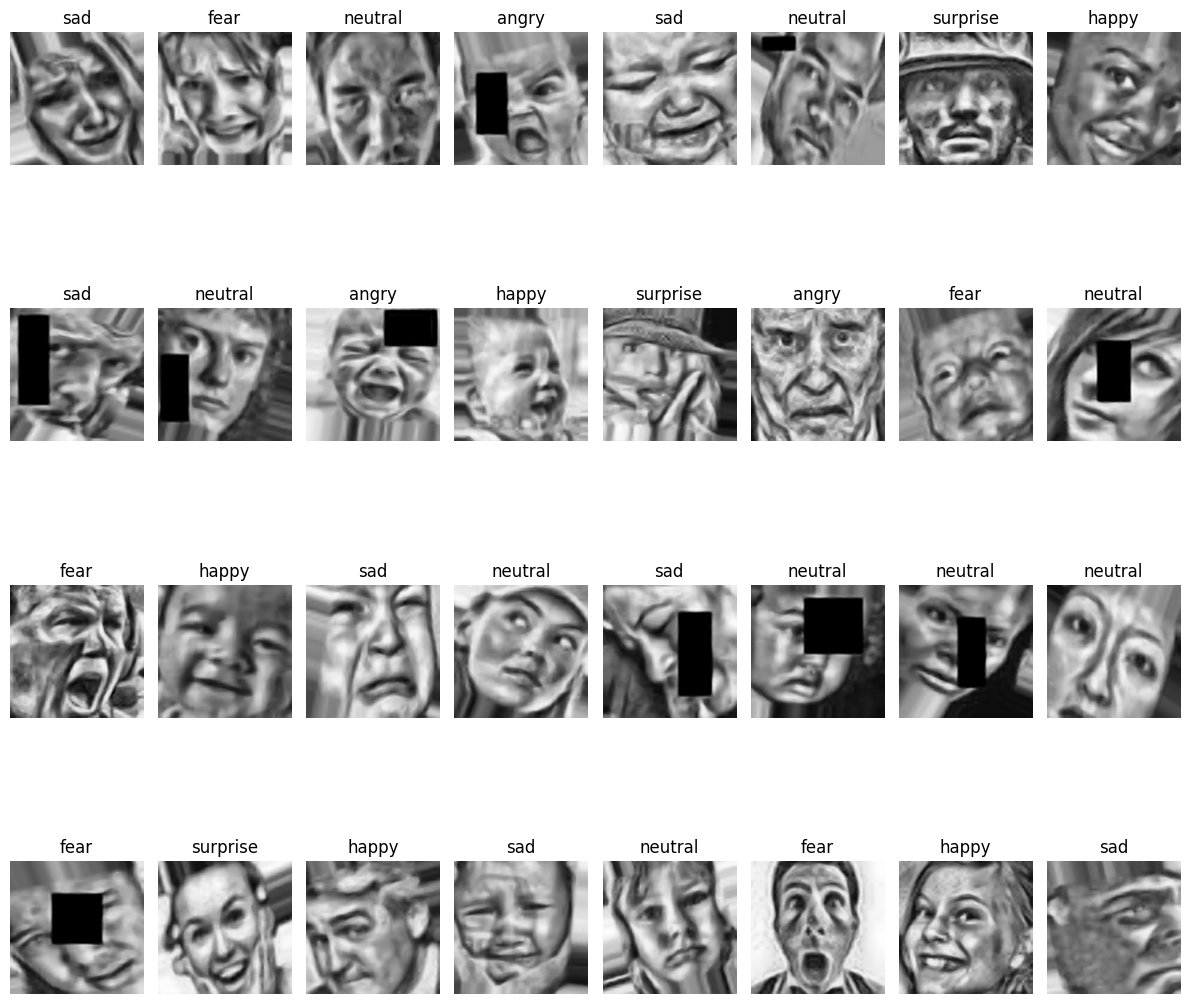

In [2]:
# Cấu hình kích thước ảnh đầu vào, batch size và seed ngẫu nhiên
IMG_SIZE = (224, 224)   # ResNet50 yêu cầu ảnh 224x224
BATCH_SIZE = 32         # Số ảnh / batch khi đưa vào mô hình
SEED = 42               # Seed cố định để việc shuffle tái lập được

# ==========================
# 1. Tạo tf.data.Dataset cho train / val / test
# ==========================

# Tập TRAIN
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,          # Resize ảnh về 224x224
    color_mode="rgb",             # 3 kênh màu RGB (phù hợp ResNet50)
    batch_size=BATCH_SIZE,
    label_mode="categorical",     # Nhãn dạng one-hot cho 7 lớp
    shuffle=True,                 # Shuffle để tránh học theo thứ tự file
    seed=SEED
)

# Tập VALIDATION
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Tập TEST
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# ==========================
# 2. In thông tin tổng quan để đưa vào báo cáo
# ==========================

# Danh sách tên lớp (7 cảm xúc) và số lớp
class_names = train_ds.class_names
num_classes = len(class_names)
print("✅ Classes:", class_names, "– num_classes =", num_classes)

# Số batch trong từng tập (ước lượng nhanh số lượng mẫu)
print("\n🔢 Số batch trong từng tập:")
print(" - Số batch train:", len(train_ds))
print(" - Số batch val  :", len(val_ds))
print(" - Số batch test :", len(test_ds))

# Hàm đếm chính xác số lượng ảnh trong mỗi tập
def count_images(dataset):
    total = 0
    for batch_images, _ in dataset:
        total += batch_images.shape[0]  # batch_size thực tế (batch cuối có thể nhỏ hơn)
    return total

n_train = count_images(train_ds)
n_val   = count_images(val_ds)
n_test  = count_images(test_ds)

print("\n📊 Số lượng ảnh thực tế:")
print(" - Số ảnh train:", n_train)
print(" - Số ảnh val  :", n_val)
print(" - Số ảnh test :", n_test)

# ==========================
# ==========================
# 3. Kiểm tra cấu trúc 1 batch & in toàn bộ ảnh kèm label
# ==========================

for images, labels in train_ds.take(1):
    # images: (BATCH_SIZE, 224, 224, 3), labels: (BATCH_SIZE, 7)
    print("\n🧩 Ví dụ 1 batch từ train_ds:")
    print(" - Shape images:", images.shape)
    print(" - Shape labels:", labels.shape)

    # In ra thông tin nhãn one-hot của từng ảnh trong batch
    print("\n📊 Nhãn one-hot của các ảnh trong batch:")
    for i in range(images.shape[0]):  # Duyệt qua tất cả ảnh trong batch
        label_vec = labels[i].numpy()
        class_idx = int(tf.argmax(label_vec).numpy())  # Lấy index lớp từ one-hot vector
        class_name = class_names[class_idx]  # Lấy tên lớp tương ứng
        print(f" - Ảnh {i}: class index = {class_idx}, lớp = {class_name}, one-hot = {label_vec}")

    # Hiển thị tất cả ảnh trong batch
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 12))
    for i in range(images.shape[0]):
        ax = plt.subplot(4, 8, i + 1)  # Chia lưới ảnh 4x4, có thể điều chỉnh
        img = images[i].numpy().astype("uint8")
        label_vec = labels[i].numpy()
        class_idx = int(tf.argmax(label_vec).numpy())
        class_name = class_names[class_idx]

        plt.imshow(img)  # Hiển thị ảnh
        plt.title(class_name)  # Ghi tên lớp lên trên ảnh
        plt.axis("off")  # Tắt trục

    plt.tight_layout()  # Căn chỉnh lại layout cho đẹp
    plt.show()
    break   # Chỉ lấy đúng 1 batch


    


### 3.Chuẩn hóa ảnh theo chuẩn của Imagenet

In [3]:
# Import hàm preprocess_input từ ResNet50, dùng để tiền xử lý ảnh cho phù hợp với mô hình ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Cấu hình AUTOTUNE giúp TensorFlow tự động tối ưu hóa việc tải dữ liệu
AUTOTUNE = tf.data.AUTOTUNE

# Định nghĩa hàm preprocess để chuẩn hóa ảnh và nhãn
def preprocess(img, label):
    img = tf.cast(img, tf.float32)  # Chuyển ảnh sang kiểu float32 để có thể xử lý
    img = preprocess_input(img)     # Tiền xử lý ảnh theo chuẩn của ResNet50 (mean subtraction)
    return img, label

# Áp dụng hàm preprocess cho các tập train, validation và test
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Lấy 1 batch ảnh từ train_ds để kiểm tra sau khi preprocess
for images, labels in train_ds.take(1):
    img = images[0].numpy()   # Lấy ảnh đầu tiên trong batch và chuyển thành numpy array
    label = labels[0].numpy()  # Lấy nhãn (one-hot) tương ứng với ảnh đầu tiên

    # In ra nhãn one-hot của ảnh đầu tiên
    print("🔹 Label one-hot:", label)
    # In ra kích thước của ảnh
    print("🔹 Shape ảnh:", img.shape)  # (224, 224, 3)

    # In ra ma trận 5x5 đầu tiên của kênh R (Red) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh R):")
    print(img[:5, :5, 0])

    # In ra ma trận 5x5 đầu tiên của kênh G (Green) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh G):")
    print(img[:5, :5, 1])

    # In ra ma trận 5x5 đầu tiên của kênh B (Blue) trong ảnh
    print("\n🔹 Ma trận 5x5 đầu tiên (kênh B):")
    print(img[:5, :5, 2])


🔹 Label one-hot: [0. 0. 0. 0. 1. 0. 0.]
🔹 Shape ảnh: (224, 224, 3)

🔹 Ma trận 5x5 đầu tiên (kênh R):
[[123.061 124.061 125.061 125.061 125.061]
 [123.061 124.061 125.061 125.061 125.061]
 [125.061 126.061 127.061 126.061 126.061]
 [126.061 128.061 129.061 129.061 128.061]
 [127.061 129.061 131.061 131.061 130.061]]

🔹 Ma trận 5x5 đầu tiên (kênh G):
[[110.221 111.221 112.221 112.221 112.221]
 [110.221 111.221 112.221 112.221 112.221]
 [112.221 113.221 114.221 113.221 113.221]
 [113.221 115.221 116.221 116.221 115.221]
 [114.221 116.221 118.221 118.221 117.221]]

🔹 Ma trận 5x5 đầu tiên (kênh B):
[[103.32 104.32 105.32 105.32 105.32]
 [103.32 104.32 105.32 105.32 105.32]
 [105.32 106.32 107.32 106.32 106.32]
 [106.32 108.32 109.32 109.32 108.32]
 [107.32 109.32 111.32 111.32 110.32]]


### 4.Xây dựng mô hình phân loại cảm xúc với ResNet50.



In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

# Tải mô hình ResNet50 đã được huấn luyện trên ImageNet mà không có phần fully connected (FC) cuối
base_model = ResNet50(
    weights="/kaggle/input/resnet/tensorflow2/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5",  # dùng trọng số học sẵn trên ImageNet
    include_top=False,  # Bỏ phần FC cuối cùng của ImageNet (tránh overfitting trên dataset nhỏ hơn)
    input_shape=(224, 224, 3)  # Định dạng đầu vào là ảnh 224x224 với 3 kênh (RGB)
)

# Giai đoạn 1: Không cập nhật trọng số của ResNet
base_model.trainable = False  # Khóa các trọng số của mô hình ResNet, giữ nguyên các trọng số đã học

# Định nghĩa đầu vào của mô hình (ảnh có kích thước 224x224 và 3 kênh màu)
inputs = tf.keras.Input(shape=(224, 224, 3))

# Đưa ảnh vào mô hình ResNet (không train trọng số của base_model)
x = base_model(inputs, training=False)  # Pass input qua base_model, không huấn luyện trong giai đoạn này

# Sử dụng Global Average Pooling để giảm chiều của feature map (lấy trung bình các giá trị)
x = layers.GlobalAveragePooling2D()(x)  # Chuyển feature map thành vector 1 chiều

# Áp dụng Dropout để giảm overfitting (tỉ lệ dropout là 0.3)
x = layers.Dropout(0.3)(x)

# Thêm lớp Dense cuối cùng với số lượng lớp bằng số lớp cảm xúc (num_classes)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Tạo mô hình kết hợp các lớp trên (inputs và outputs)
model = models.Model(inputs, outputs)

# Định nghĩa hàm mất mát và tối ưu hóa cho mô hình
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0)  # Hàm mất mát với Categorical Crossentropy
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)  # Adam optimizer với learning rate nhỏ

# Biên dịch mô hình với hàm mất mát và tối ưu hóa đã định nghĩa
model.compile(
    optimizer=optimizer,  # Sử dụng optimizer Adam
    loss=loss_fn,  # Hàm mất mát CategoricalCrossentropy
    metrics=["accuracy"]  # Đo lường độ chính xác (accuracy)
)

# In ra thông tin mô hình (số lượng lớp, tham số, v.v.)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 5.Tính toán trọng số lớp (Class Weights) cho dữ liệu không cân bằng.

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

num_classes = 7  # Số lớp trong bài toán phân loại (hoặc có thể thay bằng len(EMOTIONS) / len(class_names))

all_labels = []  # Danh sách chứa tất cả nhãn lớp từ dữ liệu huấn luyện

# Duyệt qua toàn bộ tập huấn luyện (train_ds)
for images, labels in train_ds:
    # labels hiện là one-hot vector: (batch_size, num_classes)
    labels_idx = np.argmax(labels.numpy(), axis=1)  # Chuyển từ one-hot về chỉ số lớp (index) -> [batch_size]
    all_labels.extend(labels_idx)  # Thêm các chỉ số lớp vào danh sách

all_labels = np.array(all_labels)  # Chuyển all_labels thành một mảng numpy

# Tính toán trọng số các lớp bằng phương pháp 'balanced' (cân bằng)
class_weights = compute_class_weight(
    class_weight="balanced",  # Tính trọng số cân bằng cho mỗi lớp
    classes=np.arange(num_classes),  # Các lớp là các số nguyên từ 0 đến num_classes-1
    y=all_labels  # Dữ liệu nhãn của tất cả các ảnh trong tập huấn luyện
)

# Chuẩn hóa trọng số lớp sao cho giá trị trung bình = 1
class_weights = class_weights / class_weights.mean()   # Đảm bảo trọng số trung bình là 1

# Giới hạn trọng số lớp tối đa là 3.0 để tránh ảnh hưởng quá lớn từ lớp ít xuất hiện
class_weights = np.minimum(class_weights, 3.0)         # Giới hạn trọng số tối đa là 3.0

# Chuyển trọng số thành dictionary, với key là chỉ số lớp và value là trọng số của lớp đó
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

# In ra trọng số lớp
print("Class weights:", class_weights_dict)

Class weights: {0: 0.48031856877904827, 1: 3.0, 2: 0.46832094733667745, 3: 0.2659647577977577, 4: 0.38643967296224774, 5: 0.39726299551233507, 6: 0.6050303633433411}


### 6.Hàm đánh giá quá trình train

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def summarize_training(history, model, train_ds, val_ds, stage_name="Stage"):
    train_loss = history.history["loss"]
    val_loss   = history.history["val_loss"]
    train_acc  = history.history["accuracy"]
    val_acc    = history.history["val_accuracy"]

    epochs = len(train_loss)

    print(f"\n===================================================================")
    print(f"📈 TỔNG KẾT KẾT QUẢ TRAINING – {stage_name}")
    print("===================================================================\n")

    print(f"Số epochs train thực tế: {epochs}\n")

    print("Kết quả epoch cuối cùng (train):")
    print(f" - Loss      : {train_loss[-1]:.4f}")
    print(f" - Accuracy  : {train_acc[-1]*100:.2f}%\n")

    print("Kết quả epoch cuối cùng (validation):")
    print(f" - Val Loss  : {val_loss[-1]:.4f}")
    print(f" - Val Acc   : {val_acc[-1]*100:.2f}%\n")

    print("Best results trong quá trình training:")
    print(f" - Best Train Acc   : {max(train_acc):.4f} tại epoch {np.argmax(train_acc)}")
    print(f" - Lowest Train Loss: {min(train_loss):.4f} tại epoch {np.argmin(train_loss)}")
    print(f" - Best Val Acc     : {max(val_acc):.4f} tại epoch {np.argmax(val_acc)}")
    print(f" - Lowest Val Loss  : {min(val_loss):.4f} tại epoch {np.argmin(val_loss)}\n")

    # Vẽ biểu đồ Loss & Accuracy
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(train_loss, label="Train Loss")
    ax[0].plot(val_loss, label="Val Loss")
    ax[0].set_title(f"Loss ({stage_name})")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(train_acc, label="Train Acc")
    ax[1].plot(val_acc, label="Val Acc")
    ax[1].set_title(f"Accuracy ({stage_name})")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.show()

    # Phân tích over/under fitting nhanh
    diff_acc = train_acc[-1] - val_acc[-1]
    diff_loss = val_loss[-1] - train_loss[-1]

    print("Phân tích overfitting/underfitting (epoch cuối):")
    print(f" - Chênh lệch Acc (train - val): {diff_acc:.4f}")
    print(f" - Chênh lệch Loss (val - train): {diff_loss:.4f}")

    if diff_acc > 0.1:
        print(" 👉 Mô hình có dấu hiệu overfitting.")
    elif diff_acc < -0.05:
        print(" 👉 Mô hình có dấu hiệu underfitting (val tốt hơn train).")
    else:
        print(" 👉 Mô hình khá cân bằng giữa train và val.")

    # ============================
    # Đánh giá trên tập Validation
    # ============================
    print("\n===============================")
    print("📊 Đánh giá trên tập Validation")
    print("===============================")
    
    # Dự đoán trên tập validation
    val_preds = model.predict(val_ds, batch_size=32, verbose=1)
    val_preds = np.argmax(val_preds, axis=1)

    val_labels = []
    for images, labels in val_ds:
        val_labels.extend(np.argmax(labels.numpy(), axis=1))

    val_labels = np.array(val_labels)

    # Precision, Recall, F1-Score
    precision = precision_score(val_labels, val_preds, average="weighted")
    recall = recall_score(val_labels, val_preds, average="weighted")
    f1 = f1_score(val_labels, val_preds, average="weighted")

    print(f" - Precision   : {precision:.4f}")
    print(f" - Recall      : {recall:.4f}")
    print(f" - F1-Score    : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix (Validation)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


### 7.Freeze Backbone và Huấn luyện Bộ phân loại (Head)

Epoch 1/50


I0000 00:00:1764095482.695136      72 service.cc:148] XLA service 0x7b0a84004340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764095482.696201      72 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764095482.696222      72 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764095484.294415      72 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/3051 ━━━━━━━━━━━━━━━━━━━━ 4:34 90ms/step - accuracy: 0.1172 - loss: 1.1737   

I0000 00:00:1764095489.411893      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2675 - loss: 0.8903
Epoch 1: val_accuracy improved from -inf to 0.45736, saving model to /kaggle/working/fer_resnet_best_stage1.h5


...

3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.3967 - loss: 0.7168 - val_accuracy: 0.4859 - val_loss: 1.3846 - learning_rate: 2.0000e-04
Epoch 4/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4065 - loss: 0.7059
Epoch 4: val_accuracy improved from 0.48594 to 0.49129, saving model to /kaggle/working/fer_resnet_best_stage1.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4065 - loss: 0.7059 - val_accuracy: 0.4913 - val_loss: 1.3737 - learning_rate: 2.0000e-04
Epoch 5/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4111 - loss: 0.6989
Epoch 5: val_accuracy did not improve from 0.49129
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 322s 106ms/step - accuracy: 0.4111 - loss: 0.6989 - val_accuracy: 0.4871 - val_loss: 1.3778 - learning_rate: 2.0000e-04
Epoch 6/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4117 - loss: 0.6954
Epoch 6: val_accuracy improved from 0.49129 to 0.49686, saving model to /kaggle/working/fer_resnet_best_stage1.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4117 - loss: 0.6954 - val_accuracy: 0.4969 - val_loss: 1.3515 - learning_rate: 2.0000e-04
Epoch 7/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4161 - loss: 0.6919
Epoch 7: val_accuracy improved from 0.49686 to 0.49826, saving model to /kaggle/working/fer_resnet_best_stage1.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4161 - loss: 0.6919 - val_accuracy: 0.4983 - val_loss: 1.3587 - learning_rate: 2.0000e-04
Epoch 8/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4167 - loss: 0.6913
Epoch 8: val_accuracy did not improve from 0.49826
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 322s 106ms/step - accuracy: 0.4167 - loss: 0.6913 - val_accuracy: 0.4850 - val_loss: 1.3726 - learning_rate: 2.0000e-04
Epoch 9/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4176 - loss: 0.6915
Epoch 9: val_accuracy did not improve from 0.49826
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4176 - loss: 0.6915 - val_accuracy: 0.4980 - val_loss: 1.3475 - learning_rate: 2.0000e-04
Epoch 10/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4168 - loss: 0.6890
Epoch 10: val_accuracy did not improve from 0.49826
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4168 - loss: 0.6890 - val_accuracy: 0.4883 - val_loss: 1.3700

3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4295 - loss: 0.6727 - val_accuracy: 0.4987 - val_loss: 1.3561 - learning_rate: 1.2500e-05
Epoch 26/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4280 - loss: 0.6731
Epoch 26: val_accuracy did not improve from 0.49872

Epoch 26: ReduceLROnPlateau reducing learning rate to 3.12499992105586e-06.
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 322s 106ms/step - accuracy: 0.4280 - loss: 0.6731 - val_accuracy: 0.4952 - val_loss: 1.3558 - learning_rate: 1.2500e-05
Epoch 27/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4307 - loss: 0.6730
Epoch 27: val_accuracy did not improve from 0.49872
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 323s 106ms/step - accuracy: 0.4307 - loss: 0.6730 - val_accuracy: 0.4985 - val_loss: 1.3583 - learning_rate: 3.1250e-06
Epoch 28/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4289 - loss: 0.6706
Epoch 28: val_accuracy did not improve from 0.49872
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 322s 106ms

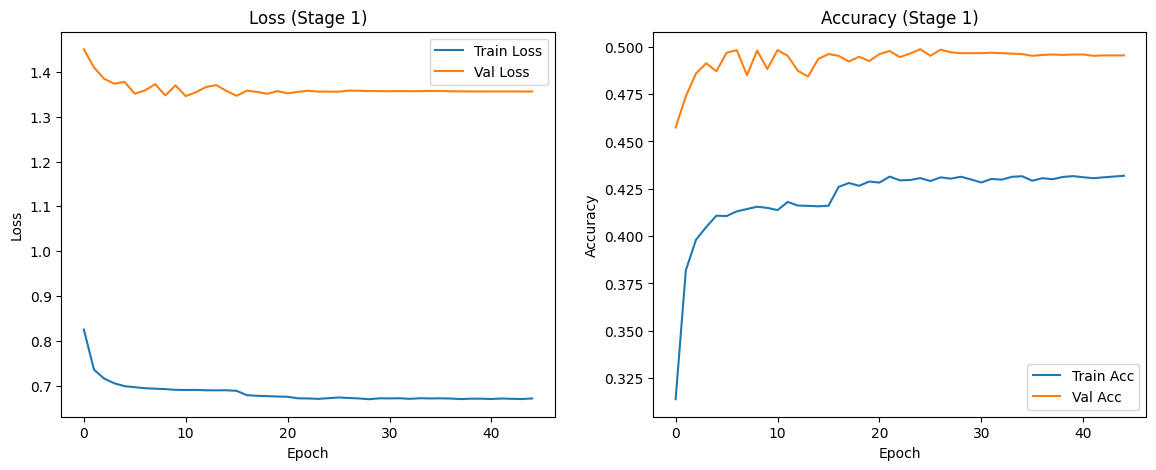

Phân tích overfitting/underfitting (epoch cuối):
 - Chênh lệch Acc (train - val): -0.0636
 - Chênh lệch Loss (val - train): 0.6850
 👉 Mô hình có dấu hiệu underfitting (val tốt hơn train).

📊 Đánh giá trên tập Validation
135/135 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step
 - Precision   : 0.5028
 - Recall      : 0.4987
 - F1-Score    : 0.4962


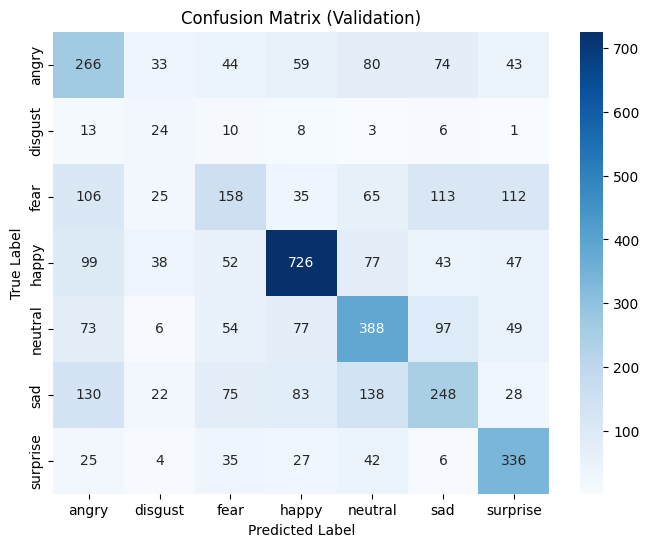

In [7]:
# Import các callback cần thiết từ Keras
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Đường dẫn để lưu trọng số mô hình tốt nhất
CHECKPOINT_PATH = "/kaggle/working/fer_resnet_best_stage1.h5"

# Định nghĩa các callback dùng trong quá trình huấn luyện
callbacks = [
    # ModelCheckpoint lưu mô hình tốt nhất dựa trên validation accuracy
    ModelCheckpoint(
        CHECKPOINT_PATH,                # Đường dẫn để lưu mô hình
        monitor="val_accuracy",         # Theo dõi validation accuracy để lưu mô hình tốt nhất
        mode="max",                     # Chọn mô hình có validation accuracy cao nhất
        save_best_only=True,            # Chỉ lưu mô hình tốt nhất
        save_weights_only=False,        # Lưu cả mô hình và trọng số (không chỉ trọng số)
        verbose=1                        # In ra thông tin mỗi khi mô hình được lưu
    ),
    # ReduceLROnPlateau giảm learning rate khi validation loss không cải thiện sau số epoch nhất định
    ReduceLROnPlateau(
        monitor="val_loss",             # Theo dõi validation loss
        factor=0.25,                    # Giảm learning rate xuống còn 25% mỗi khi không cải thiện
        patience=5,                     # Chờ 5 epoch mà validation loss không cải thiện
        verbose=1                       # In ra thông tin mỗi khi learning rate được giảm
    ),
    # EarlyStopping dừng huấn luyện nếu validation accuracy không cải thiện trong một thời gian dài
    EarlyStopping(
        monitor="val_accuracy",         # Theo dõi validation accuracy
        mode="max",                     # Dừng nếu validation accuracy không cải thiện
        patience=20,                    # Dừng sau 20 epoch mà không có sự cải thiện
        restore_best_weights=True,      # Khôi phục trọng số của mô hình tốt nhất sau khi dừng
        verbose=1                        # In ra thông tin khi huấn luyện dừng
    )
]

# Số lượng epoch cho giai đoạn 1, có thể điều chỉnh nếu cần
EPOCHS_1 = 50  # Có thể tăng lên nếu thấy mô hình chưa hội tụ

# Bắt đầu huấn luyện mô hình
history_1 = model.fit(
    train_ds,                           # Dữ liệu huấn luyện
    validation_data=val_ds,             # Dữ liệu validation
    epochs=EPOCHS_1,                    # Số lượng epoch
    callbacks=callbacks,                # Sử dụng các callback đã định nghĩa
    class_weight=class_weights_dict     # Trọng số các lớp để xử lý mất cân bằng
)

# Tổng kết kết quả huấn luyện và vẽ biểu đồ, phân tích overfitting/underfitting
summarize_training(history_1, model, train_ds, val_ds, stage_name="Stage 1")

### 8.Huấn luyện Fine-tune với một phần mô hình ResNet

Epoch 1/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4265 - loss: 0.7339
Epoch 1: val_accuracy improved from -inf to 0.53010, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 399s 126ms/step - accuracy: 0.4265 - loss: 0.7339 - val_accuracy: 0.5301 - val_loss: 1.4101 - learning_rate: 1.0000e-05
Epoch 2/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4734 - loss: 0.6684
Epoch 2: val_accuracy improved from 0.53010 to 0.55450, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.4734 - loss: 0.6684 - val_accuracy: 0.5545 - val_loss: 1.3727 - learning_rate: 1.0000e-05
Epoch 3/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5099 - loss: 0.6295
Epoch 3: val_accuracy improved from 0.55450 to 0.57053, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 372s 122ms/step - accuracy: 0.5099 - loss: 0.6295 - val_accuracy: 0.5705 - val_loss: 1.3424 - learning_rate: 1.0000e-05
Epoch 4/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5475 - loss: 0.5944
Epoch 4: val_accuracy improved from 0.57053 to 0.57843, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 371s 122ms/step - accuracy: 0.5475 - loss: 0.5944 - val_accuracy: 0.5784 - val_loss: 1.3304 - learning_rate: 1.0000e-05
Epoch 5/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5798 - loss: 0.5654
Epoch 5: val_accuracy improved from 0.57843 to 0.58169, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.5798 - loss: 0.5654 - val_accuracy: 0.5817 - val_loss: 1.3204 - learning_rate: 1.0000e-05
Epoch 6/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6127 - loss: 0.5382
Epoch 6: val_accuracy improved from 0.58169 to 0.58889, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.6127 - loss: 0.5382 - val_accuracy: 0.5889 - val_loss: 1.3098 - learning_rate: 1.0000e-05
Epoch 7/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6435 - loss: 0.5131
Epoch 7: val_accuracy improved from 0.58889 to 0.59912, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 374s 122ms/step - accuracy: 0.6435 - loss: 0.5131 - val_accuracy: 0.5991 - val_loss: 1.3061 - learning_rate: 1.0000e-05
Epoch 8/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6782 - loss: 0.4879
Epoch 8: val_accuracy improved from 0.59912 to 0.59981, saving model to /kaggle/working/fer_resnet_best_finetune.h5


3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.6782 - loss: 0.4879 - val_accuracy: 0.5998 - val_loss: 1.3096 - learning_rate: 1.0000e-05
Epoch 9/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7138 - loss: 0.4619
Epoch 9: val_accuracy did not improve from 0.59981
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.7138 - loss: 0.4619 - val_accuracy: 0.5984 - val_loss: 1.3214 - learning_rate: 1.0000e-05
Epoch 10/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7492 - loss: 0.4359
Epoch 10: val_accuracy did not improve from 0.59981

Epoch 10: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 372s 122ms/step - accuracy: 0.7492 - loss: 0.4359 - val_accuracy: 0.5989 - val_loss: 1.3354 - learning_rate: 1.0000e-05
Epoch 11/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7894 - loss: 0.4074
Epoch 11: val_accuracy improved from 0.59981 to 0.60493, saving model to /kaggle/working/fer_r

3051/3051 ━━━━━━━━━━━━━━━━━━━━ 374s 122ms/step - accuracy: 0.7894 - loss: 0.4074 - val_accuracy: 0.6049 - val_loss: 1.3387 - learning_rate: 2.5000e-06
Epoch 12/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8019 - loss: 0.3985
Epoch 12: val_accuracy did not improve from 0.60493
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 373s 122ms/step - accuracy: 0.8019 - loss: 0.3985 - val_accuracy: 0.6040 - val_loss: 1.3467 - learning_rate: 2.5000e-06
Epoch 13/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8160 - loss: 0.3891
Epoch 13: val_accuracy did not improve from 0.60493

Epoch 13: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-07.
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 371s 122ms/step - accuracy: 0.8160 - loss: 0.3891 - val_accuracy: 0.6021 - val_loss: 1.3509 - learning_rate: 2.5000e-06
Epoch 14/50
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8254 - loss: 0.3825
Epoch 14: val_accuracy did not improve from 0.60493
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 372s 122ms

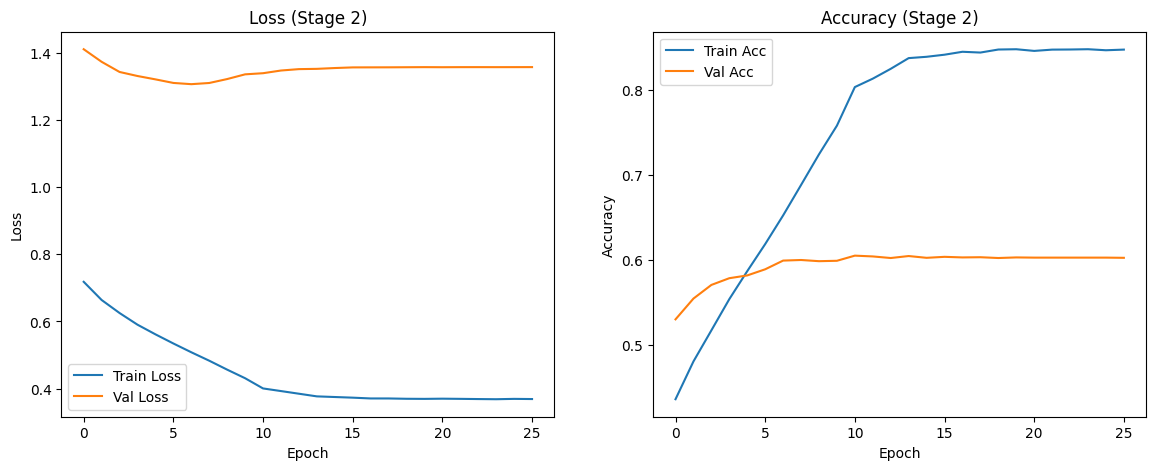

Phân tích overfitting/underfitting (epoch cuối):
 - Chênh lệch Acc (train - val): 0.2446
 - Chênh lệch Loss (val - train): 0.9880
 👉 Mô hình có dấu hiệu overfitting.

📊 Đánh giá trên tập Validation
135/135 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step
 - Precision   : 0.6054
 - Recall      : 0.6049
 - F1-Score    : 0.6035


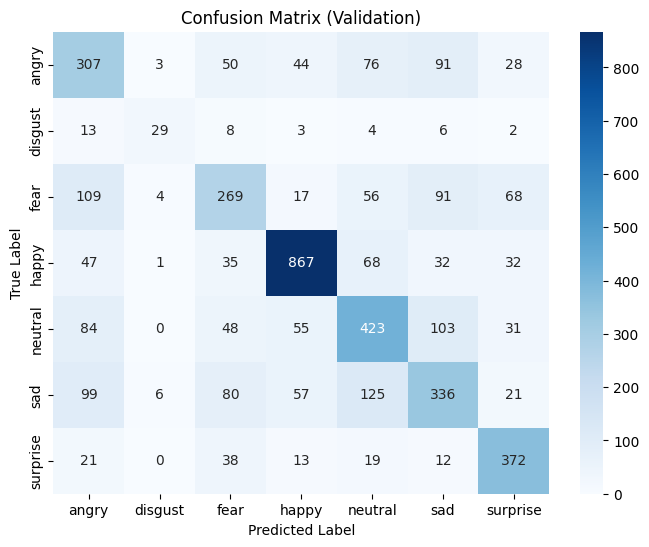

In [8]:
fine_tune_at = 160   # ví dụ mở từ layer 160 trở đi, bạn có thể chỉnh

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

CHECKPOINT_PATH_FT = "/kaggle/working/fer_resnet_best_finetune.h5"

callbacks_ft = [
    ModelCheckpoint(
        CHECKPOINT_PATH_FT,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.25,
        patience=3,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

EPOCHS_2 = 50

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_2,
    callbacks=callbacks_ft,
    class_weight=class_weights_dict
)
summarize_training(history_2, model, train_ds, val_ds, stage_name="Stage 2")

### 9.Đánh giá mô hình sau khi train trên tập test

225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - accuracy: 0.5635 - loss: 1.4316

🎯 Kết quả trên TEST SET:
 - Test Loss: 1.3522
 - Test Acc : 59.61%
225/225 ━━━━━━━━━━━━━━━━━━━━ 25s 109ms/step

📊 Các chỉ số đánh giá chi tiết trên TEST set:
 - Precision   : 0.5970
 - Recall      : 0.5961
 - F1-Score    : 0.5954


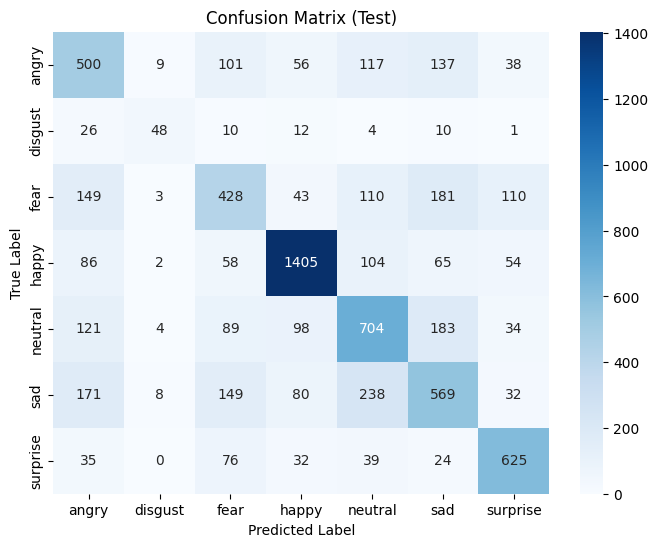


📈 Phân tích overfitting/underfitting (test vs. validation):
 - Chênh lệch Acc (test - val): -0.0088
 👉 Mô hình khá cân bằng giữa test và val.


In [9]:
# Giả sử bạn đã có giá trị val_acc từ quá trình huấn luyện
val_acc = history_2.history['val_accuracy']

# Đánh giá mô hình trên test set
test_loss, test_acc = model.evaluate(test_ds)
print("\n🎯 Kết quả trên TEST SET:")
print(f" - Test Loss: {test_loss:.4f}")
print(f" - Test Acc : {test_acc*100:.2f}%")

# ============================
# Đánh giá chi tiết với các chỉ số khác
# ============================
# Dự đoán trên tập test
test_preds = model.predict(test_ds, batch_size=32, verbose=1)
test_preds = np.argmax(test_preds, axis=1)

# Lấy nhãn thật từ test_ds
test_labels = []
for images, labels in test_ds:
    test_labels.extend(np.argmax(labels.numpy(), axis=1))
test_labels = np.array(test_labels)

# Precision, Recall, F1-Score
precision = precision_score(test_labels, test_preds, average="weighted")
recall = recall_score(test_labels, test_preds, average="weighted")
f1 = f1_score(test_labels, test_preds, average="weighted")

print("\n📊 Các chỉ số đánh giá chi tiết trên TEST set:")
print(f" - Precision   : {precision:.4f}")
print(f" - Recall      : {recall:.4f}")
print(f" - F1-Score    : {f1:.4f}")

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Test)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Phân tích over/under fitting nhanh trên test set
diff_acc = test_acc - max(val_acc)  # So sánh với val_accuracy cao nhất

print("\n📈 Phân tích overfitting/underfitting (test vs. validation):")
print(f" - Chênh lệch Acc (test - val): {diff_acc:.4f}")

if diff_acc > 0.1:
    print(" 👉 Mô hình có dấu hiệu overfitting.")
elif diff_acc < -0.05:
    print(" 👉 Mô hình có dấu hiệu underfitting (test tốt hơn val).")
else:
    print(" 👉 Mô hình khá cân bằng giữa test và val.")
